In [188]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [189]:
DATA_PATH = Path("../data/processed/tickets_with_escalation_and_resolution.csv")

df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.columns.tolist())
df.head()

(8469, 31)
['ticket_id', 'customer_name', 'customer_email', 'customer_age', 'customer_gender', 'product_purchased', 'date_of_purchase', 'ticket_type', 'ticket_subject', 'ticket_description', 'ticket_status', 'resolution', 'ticket_priority', 'ticket_channel', 'first_response_time', 'time_to_resolution', 'customer_satisfaction_rating', 'ticket_text', 'text_length', 'word_count', 'has_urgent_keyword', 'has_payment_keyword', 'has_login_keyword', 'has_error_keyword', 'customer_tier', 'affected_users', 'previous_tickets_count', 'created_hour', 'escalation_probability_true', 'is_escalated', 'resolution_time_hours']


,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,...,has_payment_keyword,has_login_keyword,has_error_keyword,customer_tier,affected_users,previous_tickets_count,created_hour,escalation_probability_true,is_escalated,resolution_time_hours
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,...,1,0,1,standard,100,3,0,0.822229,1,19.111014
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,...,0,0,1,enterprise,10,2,14,0.740507,0,10.748864
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,...,1,0,0,premium,50,1,15,0.658627,1,16.053289
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,...,0,1,1,standard,1,7,9,0.517685,1,16.796999
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,...,0,0,1,free,5,1,19,0.364433,1,11.221525


In [190]:
if "ticket_text" not in df.columns:
    text_candidates = [
        "ticket_subject",
        "subject",
        "title",
        "ticket_description",
        "description",
        "text",
        "ticket_body"
    ]

    existing_text_cols = [col for col in text_candidates if col in df.columns]

    if existing_text_cols:
        df["ticket_text"] = df[existing_text_cols].fillna("").astype(str).agg(" ".join, axis=1)
    else:
        raise ValueError("No text column found. Please check dataset columns.")

df["ticket_text"] = df["ticket_text"].fillna("").astype(str)

df[["ticket_text"]].head()

,ticket_text
0,Product setup I'm having an issue with the {pr...
1,Peripheral compatibility I'm having an issue w...
2,Network problem I'm facing a problem with my {...
3,Account access I'm having an issue with the {p...
4,Data loss I'm having an issue with the {produc...


In [191]:
df["ticket_text_clean"] = (
    df["ticket_text"]
    .str.lower()
    .str.replace(r"[^a-zA-Z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df["ticket_text_clean"].head()

0    product setup i m having an issue with the pro...
1    peripheral compatibility i m having an issue w...
2    network problem i m facing a problem with my p...
3    account access i m having an issue with the pr...
4    data loss i m having an issue with the product...
Name: ticket_text_clean, dtype: str

In [192]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.90
)

X_tfidf = vectorizer.fit_transform(df["ticket_text_clean"])

X_tfidf.shape

(8469, 3186)

In [193]:
k_values = range(3, 11)

cluster_results = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = kmeans.fit_predict(X_tfidf)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_tfidf, labels)

    cluster_results.append({
        "k": k,
        "inertia": inertia,
        "silhouette_score": silhouette
    })

cluster_results_df = pd.DataFrame(cluster_results)
cluster_results_df

,k,inertia,silhouette_score
0,3,7768.639775,0.028759
1,4,7621.920216,0.038246
2,5,7491.475284,0.044643
3,6,7344.785140,0.053715
4,7,7174.468085,0.065914
5,8,7057.698261,0.072743
6,9,6869.408834,0.084838
7,10,6768.444334,0.090533


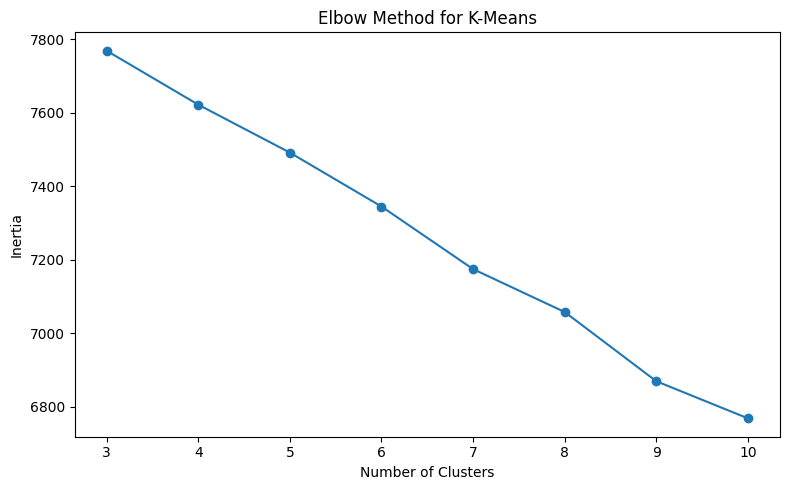

In [194]:
plt.figure(figsize=(8, 5))
plt.plot(cluster_results_df["k"], cluster_results_df["inertia"], marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.tight_layout()
plt.show()

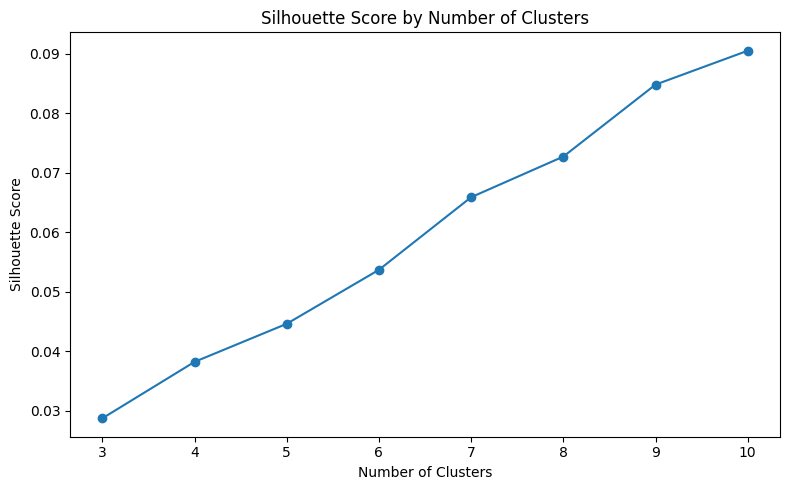

In [195]:
plt.figure(figsize=(8, 5))
plt.plot(cluster_results_df["k"], cluster_results_df["silhouette_score"], marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.tight_layout()
plt.show()

In [196]:
best_k = 10

kmeans_model = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10
)

df["cluster_id"] = kmeans_model.fit_predict(X_tfidf)

df["cluster_id"].value_counts().sort_index()

cluster_id
0     459
1     490
2     970
3     955
4     975
5     472
6     499
7     502
8    2702
9     445
Name: count, dtype: int64

In [197]:
df["cluster_id"].value_counts(normalize=True).sort_index() * 100

cluster_id
0     5.419766
1     5.785807
2    11.453536
3    11.276420
4    11.512575
5     5.573267
6     5.892077
7     5.927500
8    31.904593
9     5.254457
Name: proportion, dtype: float64

In [198]:
terms = vectorizer.get_feature_names_out()
centroids = kmeans_model.cluster_centers_

def get_top_keywords_per_cluster(centroids, terms, top_n=15):
    cluster_keywords = {}

    for cluster_id, centroid in enumerate(centroids):
        top_indices = centroid.argsort()[::-1][:top_n]
        top_terms = [terms[i] for i in top_indices]
        cluster_keywords[cluster_id] = top_terms

    return cluster_keywords

cluster_keywords = get_top_keywords_per_cluster(centroids, terms, top_n=15)

for cluster_id, keywords in cluster_keywords.items():
    print(f"Cluster {cluster_id}:")
    print(", ".join(keywords))
    print()

Cluster 0:
multiple times, issue remains, remains unresolved, remains, unresolved, support multiple, contacted customer, times issue, ve contacted, contacted, customer support, customer, multiple, times, support

Cluster 1:
action product, guide steps, desired action, purchased guide, unable option, perform desired, option perform, desired, guide, action, perform, option, unable, steps, having

Cluster 2:
troubleshooting steps, troubleshooting, steps, user manual, manual issue, steps mentioned, mentioned user, manual, mentioned, user, ve, issue persists, persists, sudden, sudden decrease

Cluster 3:
started, update, changes device, haven changes, recent software, update haven, started occurring, occurring recent, occurring, software update, problem started, recent, haven, happening, happening afterward

Cluster 4:
ve tried, tried, persists, issue persists, different, ve, purchased issue, settings configurations, different settings, configurations product, configurations, tried differen

In [199]:
for cluster_id in sorted(df["cluster_id"].unique()):
    print("=" * 100)
    print(f"Cluster {cluster_id}")
    print("Top keywords:", ", ".join(cluster_keywords[cluster_id][:10]))
    print("-" * 100)

    sample_tickets = df[df["cluster_id"] == cluster_id]["ticket_text"].sample(
        min(5, len(df[df["cluster_id"] == cluster_id])),
        random_state=RANDOM_STATE
    )

    for ticket in sample_tickets:
        print(ticket[:500])
        print("-" * 50)

Cluster 0
Top keywords: multiple times, issue remains, remains unresolved, remains, unresolved, support multiple, contacted customer, times issue, ve contacted, contacted
----------------------------------------------------------------------------------------------------
Product recommendation I'm encountering a software bug in the {product_purchased}. Whenever I try to perform a specific action, the application crashes. Are there any updates or fixes available?

If not, please send an email. I've already contacted customer support multiple times, but the issue remains unresolved.
--------------------------------------------------
Account access I'm having an issue with the {product_purchased}. Please assist. #include <iostream> struct cmp { std::shared_ptr<dtor> id; } cmp::id; void main() { int I've already contacted customer support multiple times, but the issue remains unresolved.
--------------------------------------------------
Product setup I'm having an issue with the {product_

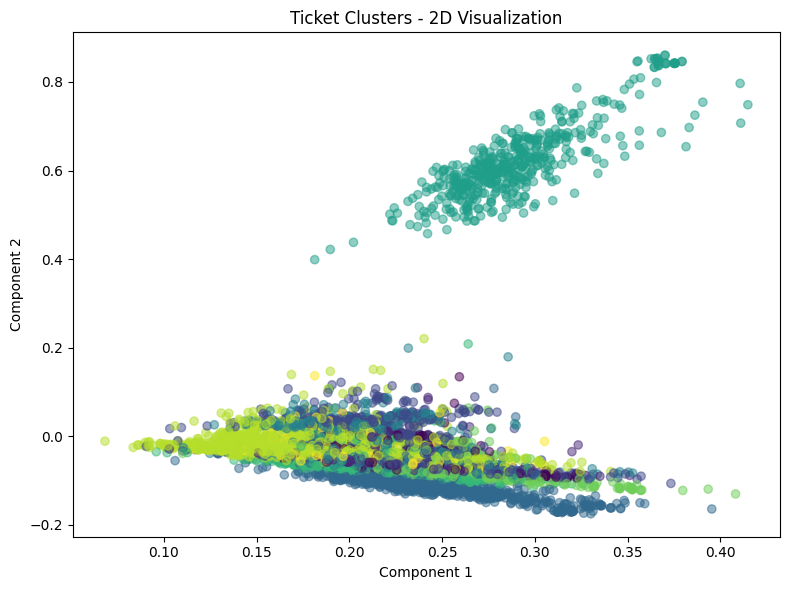

In [200]:
svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
X_2d = svd.fit_transform(X_tfidf)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=df["cluster_id"],
    alpha=0.5
)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Ticket Clusters - 2D Visualization")
plt.tight_layout()
plt.show()

In [201]:
clustering_pipeline = Pipeline(steps=[
    ("tfidf", vectorizer),
    ("kmeans", kmeans_model)
])

MODEL_PATH = Path("../models/ticket_clustering_model.pkl")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(clustering_pipeline, MODEL_PATH)

print(f"Saved clustering model to {MODEL_PATH}")

Saved clustering model to ..\models\ticket_clustering_model.pkl


In [202]:
loaded_cluster_model = joblib.load(MODEL_PATH)

sample_text = [
    "Customer cannot login to account after password reset."
]

loaded_cluster_model.predict(sample_text)

array([8], dtype=int32)

In [203]:
processed_path = Path("../data/processed/tickets_with_clusters.csv")
df.to_csv(processed_path, index=False)

processed_path

WindowsPath('../data/processed/tickets_with_clusters.csv')

In [204]:
summary_rows = []

for cluster_id in sorted(df["cluster_id"].unique()):
    summary_rows.append({
        "cluster_id": cluster_id,
        "ticket_count": int((df["cluster_id"] == cluster_id).sum()),
        "top_keywords": ", ".join(cluster_keywords[cluster_id][:10])
    })

cluster_summary_df = pd.DataFrame(summary_rows)
cluster_summary_df

,cluster_id,ticket_count,top_keywords
0,0,459,"multiple times, issue remains, remains unresol..."
1,1,490,"action product, guide steps, desired action, p..."
2,2,970,"troubleshooting steps, troubleshooting, steps,..."
3,3,955,"started, update, changes device, haven changes..."
4,4,975,"ve tried, tried, persists, issue persists, dif..."
5,5,472,"error message, message, error, popping product..."
6,6,499,"intermittent, acts, acts unexpectedly, facing ..."
7,7,502,"purchased hoping, didn help, ve performed, per..."
8,8,2702,"assist, having, issue product, having issue, p..."
9,9,445,"concerned security, like ensure, ensure data, ..."


In [205]:
summary_path = Path("../reports/metrics/cluster_summary.csv")
summary_path.parent.mkdir(parents=True, exist_ok=True)

cluster_summary_df.to_csv(summary_path, index=False)

summary_path

WindowsPath('../reports/metrics/cluster_summary.csv')